# Handwritten Digit Classification using CNN (MNIST)

## Project Objective

The objective of this project is to build an end-to-end Convolutional Neural Network (CNN) that can classify handwritten digits (0–9) using the MNIST dataset. The model is trained on grayscale images and evaluated on unseen test data with a target accuracy above 99%.

## Step 1: Import Required Libraries

In this step, we import all the required libraries for loading the dataset, preprocessing images, building the CNN model, training the model, and visualizing the results.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

**Conclusion:** All the necessary libraries were successfully imported and are ready to be used in the project.

## Step 2: Load the MNIST Dataset

The MNIST dataset contains handwritten digit images from 0 to 9. It is already divided into training and testing datasets.

In [ ]:
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


**Conclusion:** The dataset was loaded successfully with 60,000 training images and 10,000 testing images.

## Step 3: Explore the Dataset

Here we check the shape of the training and testing datasets to understand the number and size of images.

In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


**Conclusion:** Each image has a size of 28 × 28 pixels, and the dataset is properly divided into training and testing samples.

## Step 2: Load the MNIST Dataset

The MNIST dataset contains **70,000 grayscale handwritten digit images** of size **28 × 28 pixels**.

* Training images: **60,000**
* Testing images: **10,000**
* Classes: **10 digits (0–9)**

The dataset is already divided into training and testing sets.


In [ ]:
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape: (10000, 28, 28)
y_test shape: (10000,)


## Step 3: Explore Dataset Shape

This step checks the size of the training and testing datasets. It confirms the number of images and their dimensions before preprocessing.


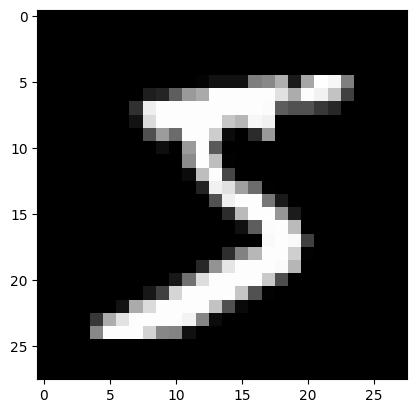

In [ ]:
plt.imshow(x_train[0], cmap="gray")
plt.show()

## Step 4: Visualize Sample Images

Here we display a handwritten digit from the dataset and its corresponding label. We also inspect the raw pixel values stored in the image matrix.


In [ ]:
print("Label:", y_train[0])

Label: 5


In [ ]:
print(x_train[0])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 18

In [ ]:
print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

Minimum pixel value: 0
Maximum pixel value: 255


In [ ]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

## Step 5: Data Preprocessing

Before training, the images are preprocessed.

**Preprocessing includes:**

* Converting pixel values to floating-point numbers.
* Normalizing pixel values from **0–255** to **0–1**.
* Reshaping images to **28 × 28 × 1** to include the grayscale channel.


noramlization


In [ ]:
print("Minimum:", x_train.min())
print("Maximum:", x_train.max())

Minimum: 0.0
Maximum: 1.0


In [ ]:
print(x_train.shape)

(60000, 28, 28)


In [ ]:
x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

In [ ]:
print(x_train.shape)
print(x_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [ ]:
model = keras.Sequential()

## Step 6: Build the CNN Model

A Convolutional Neural Network (CNN) is created layer by layer to learn important image features and classify handwritten digits.


In [ ]:
model.add(
    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        input_shape=(28, 28, 1)
    )
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Conv2D Layer 1

The first convolution layer extracts basic image features such as edges, lines, and curves using multiple filters with ReLU activation.


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 320 (1.25 KB)

 Trainable params: 320 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.add(layers.MaxPooling2D(pool_size=(2, 2)))

### MaxPooling Layer 1

This layer reduces the spatial dimensions of the feature map while keeping the most important features. It also reduces computation and helps prevent overfitting.


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 320 (1.25 KB)

 Trainable params: 320 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.add(
    layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    )
)

### Conv2D Layer 2

The second convolution layer learns more complex patterns such as shapes and digit structures from the previous feature maps.


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,816 (73.50 KB)

 Trainable params: 18,816 (73.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.add(
    layers.MaxPooling2D(
        pool_size=(2, 2)
    )
)

### MaxPooling Layer 2

This pooling layer further downsamples the feature maps and keeps the strongest activations.


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,816 (73.50 KB)

 Trainable params: 18,816 (73.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.add(
    layers.Flatten()
)

### Flatten Layer

The Flatten layer converts 2D feature maps into a 1D vector so that the data can be passed to fully connected Dense layers.


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,816 (73.50 KB)

 Trainable params: 18,816 (73.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.add(
    layers.Dense(
        128,
        activation="relu"
    )
)

### Dense Hidden Layer

This fully connected layer learns high-level features from the extracted image representations using ReLU activation.


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 223,744 (874.00 KB)

 Trainable params: 223,744 (874.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.add(
    layers.Dropout(0.5)
)

### Dropout Layer

Dropout randomly deactivates some neurons during training to reduce overfitting and improve model generalization.


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 223,744 (874.00 KB)

 Trainable params: 223,744 (874.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.add(
    layers.Dense(
        10,
        activation="softmax"
    )
)

### Output Layer

The final Dense layer has **10 neurons**, one for each digit class (0–9). Softmax converts the outputs into probabilities, and the highest probability becomes the predicted digit.


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## Step 7: Compile the CNN Model

The model is compiled by selecting:

* **Optimizer:** Adam
* **Loss Function:** Sparse Categorical Crossentropy
* **Evaluation Metric:** Accuracy

This prepares the CNN for training.


In [ ]:
history = model.fit(
    x_train,
    y_train,
    batch_size=128,
    epochs=10,
    validation_split=0.1
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 92ms/step - accuracy: 0.9033 - loss: 0.3146 - val_accuracy: 0.9803 - val_loss: 0.0593
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 38s 91ms/step - accuracy: 0.9700 - loss: 0.1008 - val_accuracy: 0.9868 - val_loss: 0.0438
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 39s 93ms/step - accuracy: 0.9772 - loss: 0.0751 - val_accuracy: 0.9895 - val_loss: 0.0337
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 38s 90ms/step - accuracy: 0.9818 - loss: 0.0600 - val_accuracy: 0.9887 - val_loss: 0.0393
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 91ms/step - accuracy: 0.9847 - loss: 0.0512 - val_accuracy: 0.9898 - val_loss: 0.0335
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 38s 90ms/step - accuracy: 0.9867 - loss: 0.0432 - val_accuracy: 0.9907 - val_loss: 0.0340
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 38s 91ms/step - accuracy: 0.9880 - loss: 0.0386 - val_accuracy: 0.9912 - val_loss: 0.0294
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 38s 91ms/step - accuracy: 0.9899 - loss: 0.0333 - 

## Step 8: Train the Model

The CNN is trained on the training dataset for multiple epochs. During training, the model updates its weights to minimize the loss and improve prediction accuracy.


In [ ]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9915 - loss: 0.0274
Test Loss: 0.027404334396123886
Test Accuracy: 0.9915000200271606


## Step 9: Evaluate Model Performance

The trained model is evaluated on unseen test images. Test loss and test accuracy measure how well the model performs on new data.


In [ ]:
y_pred = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


## Step 10: Make Predictions

The trained CNN predicts the probability for each digit class. The class with the highest probability is selected as the final prediction.


In [ ]:
y_pred_classes = np.argmax(y_pred, axis=1)

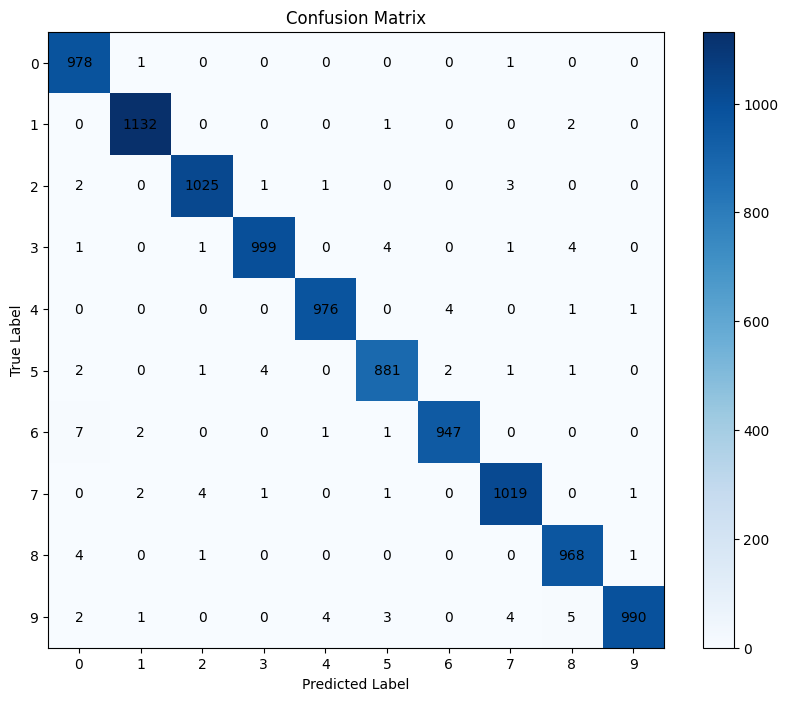

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10, 8))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

for i in range(10):
    for j in range(10):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xticks(range(10))
plt.yticks(range(10))
plt.show()

## Step 11: Confusion Matrix

A confusion matrix compares the actual labels with predicted labels. It helps identify correctly classified digits and common misclassifications.


In [ ]:
wrong_predictions = y_pred_classes != y_test

print("Number of wrong predictions:", np.sum(wrong_predictions))

Number of wrong predictions: 85


In [ ]:

confidence = np.max(y_pred, axis=1)

In [ ]:
wrong_indices = np.where(wrong_predictions)[0]

In [ ]:
high_conf_wrong = wrong_indices[
    np.argsort(confidence[wrong_indices])[::-1]
]

In [ ]:
print("Top 10 high-confidence wrong predictions:")
print(high_conf_wrong[:10])

Top 10 high-confidence wrong predictions:
[1014 2462 2135 2098 4176 9729 3520 9770 1112 2896]


## Step 12: High-Confidence Misclassifications

This section identifies images that the model predicted incorrectly with high confidence. It helps analyze challenging handwritten digits and model errors.


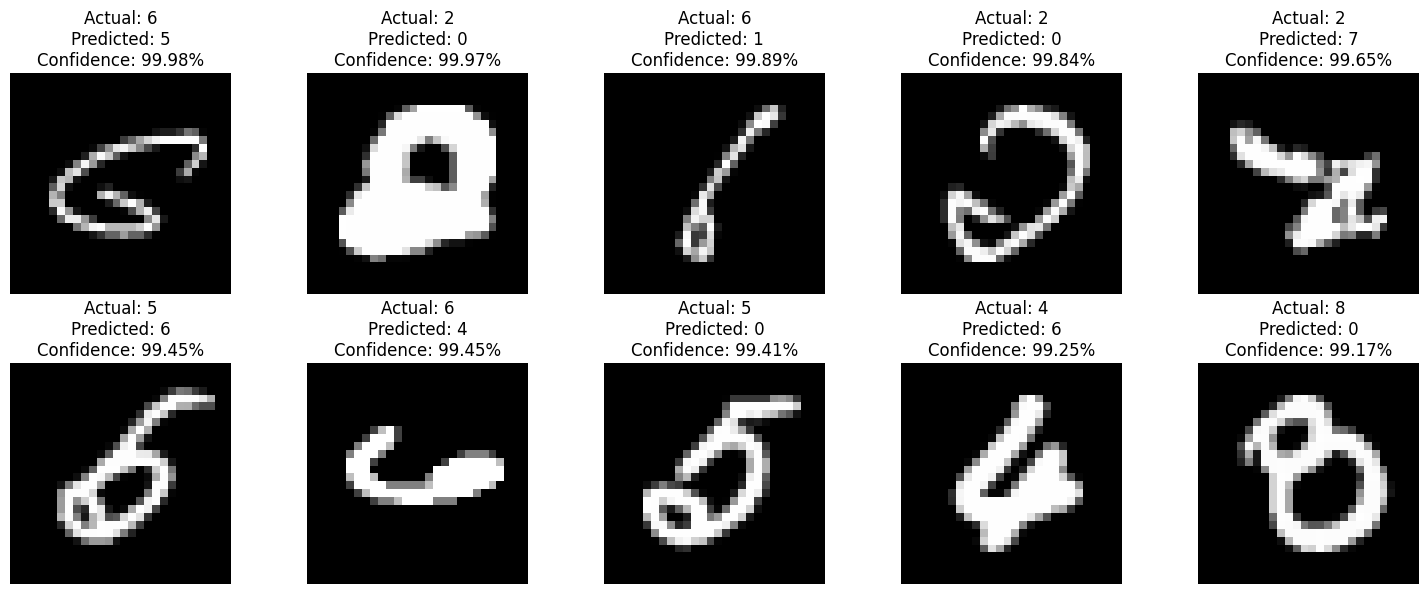

In [ ]:
plt.figure(figsize=(15, 6))

for i, index in enumerate(high_conf_wrong[:10]):
    plt.subplot(2, 5, i + 1)

    plt.imshow(x_test[index].squeeze(), cmap="gray")

    plt.title(
        f"Actual: {y_test[index]}\n"
        f"Predicted: {y_pred_classes[index]}\n"
        f"Confidence: {confidence[index]:.2%}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
data_augmentation_mild = keras.Sequential([
    layers.RandomRotation(0.05),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomZoom(0.05),
    layers.RandomShear(0.05)
])

## Step 13: Data Augmentation

Affine transformations are applied to training images to improve model robustness.

**Transformations used:**

* Rotation
* Width Shift
* Height Shift
* Zoom
* Shear


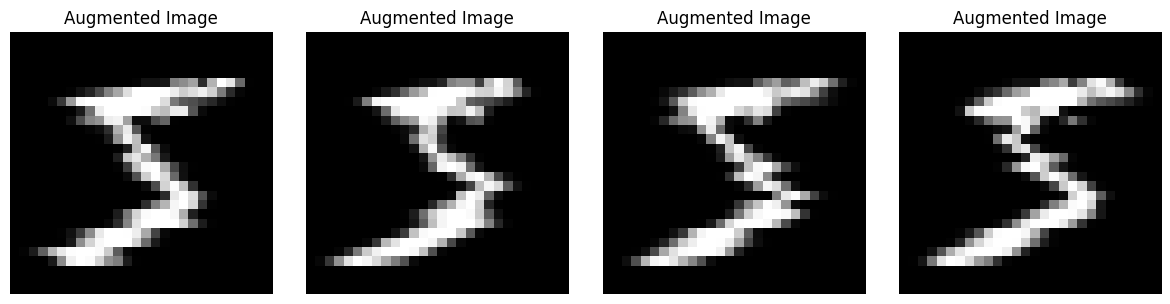

In [ ]:
image = x_train[0]

plt.figure(figsize=(12, 3))

for i in range(4):
    augmented_image = data_augmentation_mild(image)

    plt.subplot(1, 4, i + 1)

    plt.imshow(
        augmented_image.numpy().squeeze(),
        cmap="gray"
    )

    plt.title("Augmented Image")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
aug_model = keras.Sequential([

    layers.Input(shape=(28, 28, 1)),

    data_augmentation_mild,

    layers.Conv2D(
        32,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    layers.Flatten(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.5),

    layers.Dense(
        10,
        activation="softmax"
    )
])

In [ ]:
aug_model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_8 (Sequential)       │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
aug_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history_aug = aug_model.fit(
    x_train,
    y_train,
    batch_size=128,
    epochs=10,
    validation_split=0.1
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 51s 114ms/step - accuracy: 0.8484 - loss: 0.4849 - val_accuracy: 0.9730 - val_loss: 0.0847
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 47s 112ms/step - accuracy: 0.9386 - loss: 0.2031 - val_accuracy: 0.9840 - val_loss: 0.0584
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 80s 107ms/step - accuracy: 0.9519 - loss: 0.1609 - val_accuracy: 0.9858 - val_loss: 0.0476
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 83s 110ms/step - accuracy: 0.9589 - loss: 0.1352 - val_accuracy: 0.9873 - val_loss: 0.0452
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 46s 108ms/step - accuracy: 0.9658 - loss: 0.1193 - val_accuracy: 0.9878 - val_loss: 0.0468
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 46s 108ms/step - accuracy: 0.9682 - loss: 0.1054 - val_accuracy: 0.9893 - val_loss: 0.0376
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 46s 110ms/step - accuracy: 0.9707 - loss: 0.0984 - val_accuracy: 0.9895 - val_loss: 0.0428
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 81s 108ms/step - accuracy: 0.9725 - loss: 0

In [ ]:
aug_test_loss, aug_test_accuracy = aug_model.evaluate(
    x_test,
    y_test,
    verbose=1
)

print("Augmented Model Test Loss:", aug_test_loss)
print(
    "Augmented Model Test Accuracy:",
    aug_test_accuracy
)

print(
    "Augmented Model Accuracy (%):",
    aug_test_accuracy * 100
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.9923 - loss: 0.0222
Augmented Model Test Loss: 0.022164510563015938
Augmented Model Test Accuracy: 0.9922999739646912
Augmented Model Accuracy (%): 99.22999739646912


In [ ]:
print("Basic CNN Accuracy:", test_accuracy * 100)
print("Augmented CNN Accuracy:", aug_test_accuracy * 100)

difference = aug_test_accuracy - test_accuracy

print("Accuracy Difference (%):", difference * 100)

Basic CNN Accuracy: 99.15000200271606
Augmented CNN Accuracy: 99.22999739646912
Accuracy Difference (%): 0.07999539375305176


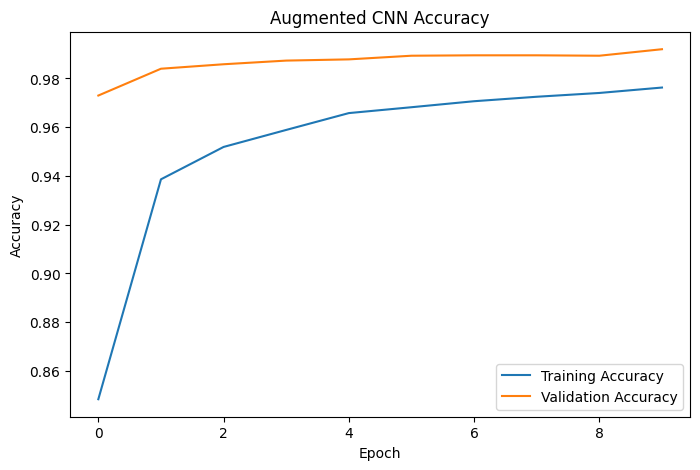

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_aug.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_aug.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Augmented CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

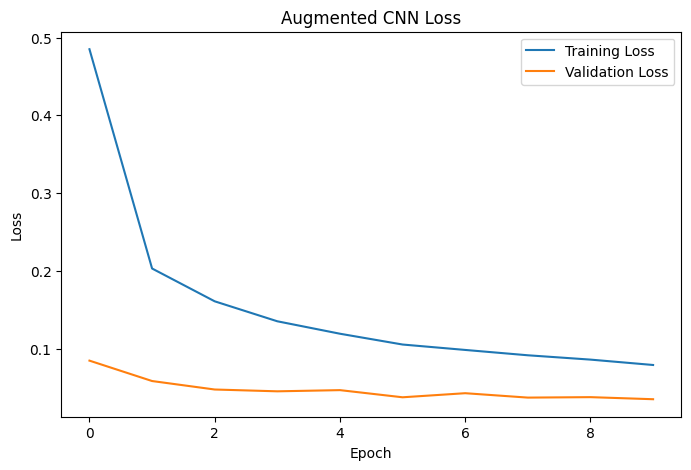

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_aug.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_aug.history["val_loss"],
    label="Validation Loss"
)

plt.title("Augmented CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
aug_y_pred = aug_model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


In [ ]:
aug_y_pred_classes = np.argmax(aug_y_pred, axis=1)

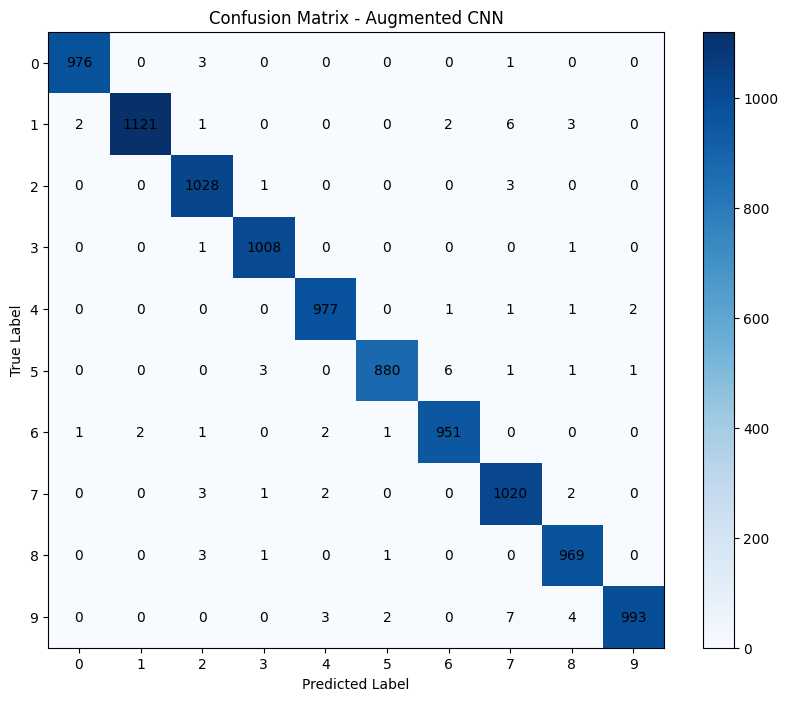

In [ ]:
from sklearn.metrics import confusion_matrix

aug_cm = confusion_matrix(
    y_test,
    aug_y_pred_classes
)

plt.figure(figsize=(10, 8))

plt.imshow(aug_cm, cmap="Blues")

plt.title("Confusion Matrix - Augmented CNN")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

for i in range(10):
    for j in range(10):
        plt.text(
            j,
            i,
            aug_cm[i, j],
            ha="center",
            va="center"
        )

plt.xticks(range(10))
plt.yticks(range(10))

plt.show()

In [ ]:
aug_wrong_predictions = (
    aug_y_pred_classes != y_test
)

print(
    "Number of wrong predictions:",
    np.sum(aug_wrong_predictions)
)

Number of wrong predictions: 77


In [ ]:
aug_confidence = np.max(
    aug_y_pred,
    axis=1
)

aug_wrong_indices = np.where(
    aug_wrong_predictions
)[0]

aug_high_conf_wrong = aug_wrong_indices[
    np.argsort(
        aug_confidence[aug_wrong_indices]
    )[::-1]
]

print(
    "Top 10 high-confidence wrong predictions:"
)

print(aug_high_conf_wrong[:10])

Top 10 high-confidence wrong predictions:
[9729 3520 9530 1364 4761 9634 2597 2939 6597 2040]


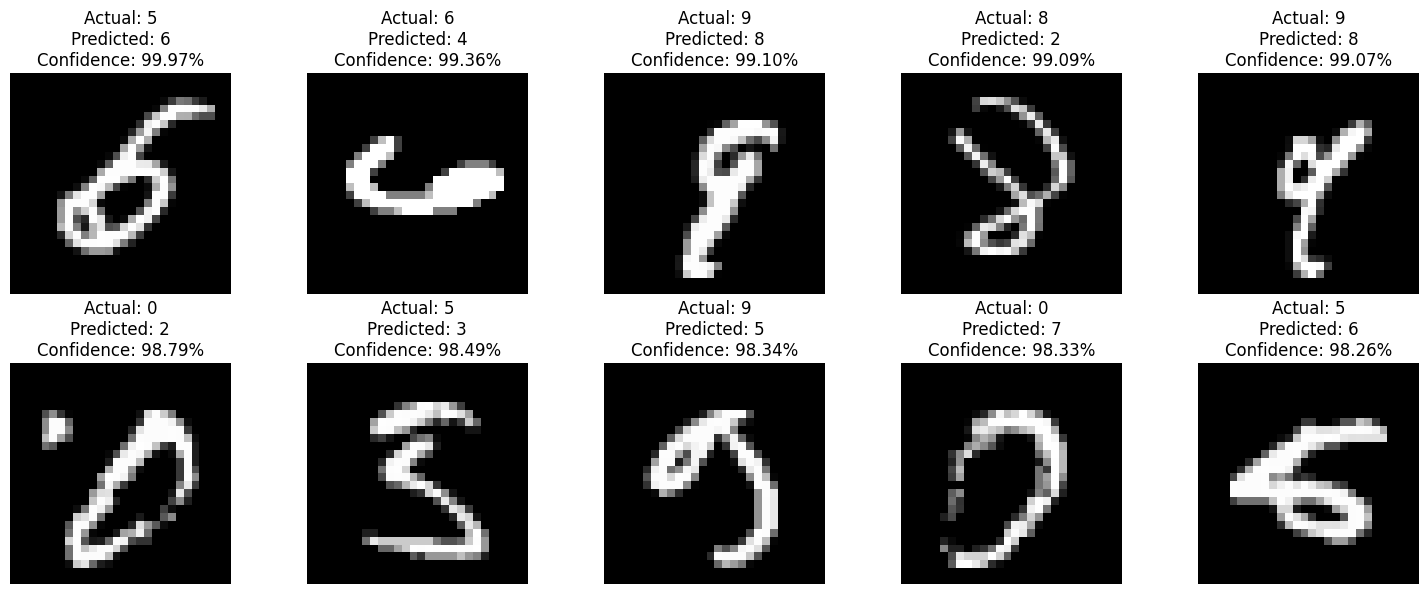

In [ ]:
plt.figure(figsize=(15, 6))

for i, index in enumerate(
    aug_high_conf_wrong[:10]
):

    plt.subplot(2, 5, i + 1)

    plt.imshow(
        x_test[index].squeeze(),
        cmap="gray"
    )

    plt.title(
        f"Actual: {y_test[index]}\n"
        f"Predicted: {aug_y_pred_classes[index]}\n"
        f"Confidence: {aug_confidence[index]:.2%}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

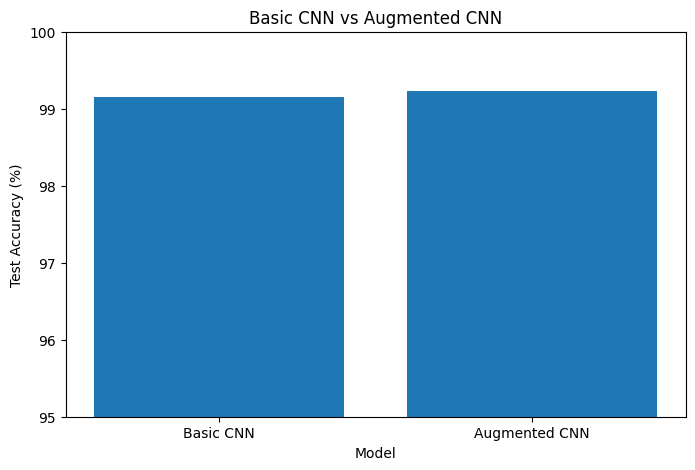

In [ ]:
models = ["Basic CNN", "Augmented CNN"]

accuracies = [
    test_accuracy * 100,
    aug_test_accuracy * 100
]

plt.figure(figsize=(8, 5))

plt.bar(models, accuracies)

plt.title("Basic CNN vs Augmented CNN")
plt.xlabel("Model")
plt.ylabel("Test Accuracy (%)")

plt.ylim(95, 100)

plt.show()

In [ ]:
print("Basic CNN Accuracy:", round(test_accuracy * 100, 2), "%")
print("Augmented CNN Accuracy:", round(aug_test_accuracy * 100, 2), "%")


Basic CNN Accuracy: 99.15 %
Augmented CNN Accuracy: 99.23 %


In [ ]:
accuracy_difference = (
    aug_test_accuracy - test_accuracy
) * 100

print("Accuracy Improvement:", round(accuracy_difference, 2), "%")

Accuracy Improvement: 0.08 %


In [ ]:
print("========== PROJECT SUMMARY ==========")

print("Dataset: MNIST")
print("Image Size: 28 x 28")
print("Number of Classes: 10")

print(
    "Basic CNN Accuracy:",
    round(test_accuracy * 100, 2),
    "%"
)

print(
    "Augmented CNN Accuracy:",
    round(aug_test_accuracy * 100, 2),
    "%"
)

print(
    "Accuracy Improvement:",
    round(accuracy_difference, 2),
    "percentage points"
)

print(
    "Basic CNN Wrong Predictions:",
    np.sum(wrong_predictions)
)

print(
    "Augmented CNN Wrong Predictions:",
    np.sum(aug_wrong_predictions)
)

========== PROJECT SUMMARY ==========
Dataset: MNIST
Image Size: 28 x 28
Number of Classes: 10
Basic CNN Accuracy: 99.15 %
Augmented CNN Accuracy: 99.23 %
Accuracy Improvement: 0.08 percentage points
Basic CNN Wrong Predictions: 85
Augmented CNN Wrong Predictions: 77


## Step 15: Project Conclusion

The CNN model successfully classifies handwritten digits from **0–9** using the MNIST dataset.

**Summary**

* Loaded and explored the MNIST dataset.
* Preprocessed images using normalization and reshaping.
* Built a CNN with Conv2D, MaxPooling, Flatten, Dense, and Dropout layers.
* Trained and evaluated the model.
* Visualized performance using a confusion matrix.
* Analyzed high-confidence misclassified images.
* Improved robustness using data augmentation.
